In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [3]:
df = pd.read_csv('orwe_data_features.csv')

In [4]:
df

,Date,Close,High,Low,Open,Volume,return_1d,return_5d,return_10d,ma_10,ma_50,ma_ratio_10,ma_ratio_50,rsi,macd,macd_signal,macd_hist,volatility_10,volatility_20,volume_avg_10,volume_ratio,target
0,2018-03-11,5.172830,5.262681,5.134323,5.156786,414339,0.003111,0.006871,0.073236,5.107368,5.174242,1.012817,0.999727,58.754901,0.002184,-0.025990,0.028174,0.016413,0.015424,742887.3,0.557741,1
1,2018-03-12,5.233800,5.307606,5.137531,5.172830,2267233,0.011787,0.030322,0.048875,5.131756,5.172445,1.019885,1.011862,61.594235,0.014021,-0.017988,0.032009,0.013342,0.015179,743148.3,3.050849,0
2,2018-03-14,5.150368,5.237010,5.073353,5.156786,829527,-0.015941,0.019695,0.000000,5.139778,5.168209,1.002060,0.996548,73.913209,0.023356,-0.003139,0.026496,0.010628,0.015550,526482.4,1.575603,0
3,2018-03-15,5.079771,5.166412,4.973875,5.150367,1515634,-0.013707,-0.014935,-0.010006,5.134644,5.163011,0.989313,0.983878,66.530686,0.017632,0.001015,0.016617,0.011458,0.015932,641410.4,2.362971,0
4,2018-03-18,5.002756,5.086188,4.957830,5.079770,726843,-0.015161,-0.032878,-0.026234,5.121166,5.156272,0.976878,0.970227,50.925942,0.006803,0.002172,0.004630,0.012256,0.016137,703304.2,1.033469,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1906,2026-04-20,22.799999,22.879999,22.719999,22.780001,711529,0.000878,0.004848,0.028417,22.682000,22.722400,1.005202,1.003415,69.999981,0.070793,0.003108,0.067685,0.008239,0.009012,869319.1,0.818490,0
1907,2026-04-21,22.799999,23.000000,22.780001,22.799999,899310,0.000000,-0.004367,0.017857,22.722000,22.716400,1.003433,1.003680,71.428585,0.076974,0.017881,0.059093,0.007828,0.008905,909518.2,0.988776,0
1908,2026-04-22,22.730000,22.950001,22.650000,22.799999,1413911,-0.003070,-0.008722,0.006197,22.736000,22.706000,0.999736,1.001057,69.306896,0.075355,0.029376,0.045979,0.007580,0.008948,1005267.6,1.406502,1
1909,2026-04-23,22.750000,22.840000,22.600000,22.730000,1671736,0.000880,-0.002193,0.020179,22.781000,22.694200,0.998639,1.002459,63.742662,0.074824,0.038466,0.036358,0.005932,0.008821,1123747.4,1.487644,1


In [5]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'return_1d',
       'return_5d', 'return_10d', 'ma_10', 'ma_50', 'ma_ratio_10',
       'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist',
       'volatility_10', 'volatility_20', 'volume_avg_10', 'volume_ratio',
       'target'],
      dtype='object')

# drop some features
Claude recomends to drop the following columns
>`Close`, `High`, `Low`, `Open` *—* raw prices with no predictive signal on their own. Everything useful from them is already captured in your engineered features (`ma_ratio`, `rsi`, `macd`, etc.)

>`Volume` *—* raw volume already captured by volume_ratio

>`ma_10`, `ma_50` *—* already captured by `ma_ratio_10`, `ma_ratio_50`

>`volume_avg_10` *—* already captured by volume_ratio

>`Date` *—* not a numeric feature the model can learn from

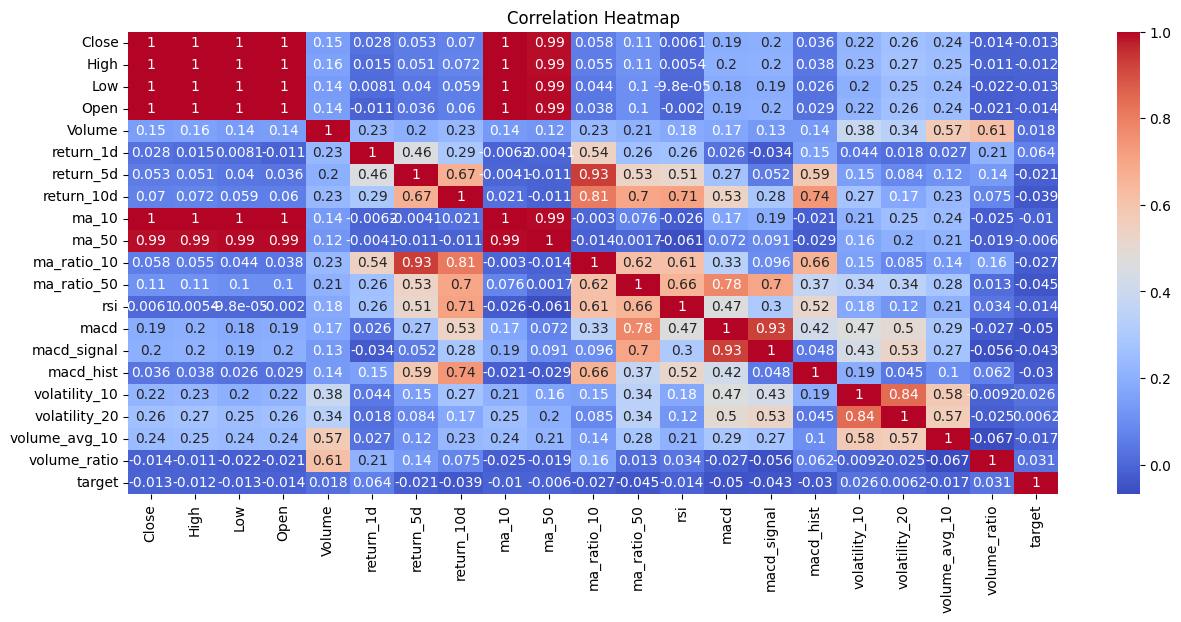

In [22]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.drop("Date", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap");

In [7]:
#Drop the features that are not needed for training the model
df_new = df.drop(["Close", "Open", "High", "Low", "Volume", "ma_10", "ma_50", "volume_avg_10", "Date"], axis=1)
df_new.columns

Index(['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50',
       'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10',
       'volatility_20', 'volume_ratio', 'target'],
      dtype='object')

# Split train-test and scalling

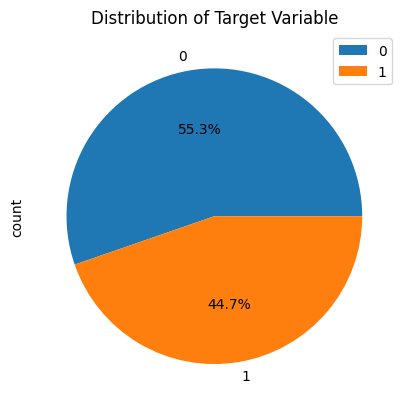

In [12]:
df_new["target"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Target Variable")
plt.legend()
plt.show()

In [ ]:
#Split the data into training and testing sets
X = df_new.drop("target", axis=1)
Y = df_new["target"]

In [15]:
split_index = int(0.8 * len(df_new))
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]

In [25]:
#Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for easier inspection later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print("\nClass balance in training set:")
print(Y_train.value_counts(normalize=True).round(2))


Class balance in training set:
target
0    0.54
1    0.46
Name: proportion, dtype: float64


In [27]:
print("Final features:", X.columns.tolist())
print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")
print("\nClass balance in training set:")
print(Y_train.value_counts(normalize=True).round(2))

Final features: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio']
Train: 1528 rows  |  Test: 383 rows

Class balance in training set:
target
0    0.54
1    0.46
Name: proportion, dtype: float64


In [28]:
X_train_scaled.head()

,return_1d,return_5d,return_10d,ma_ratio_10,ma_ratio_50,rsi,macd,macd_signal,macd_hist,volatility_10,volatility_20,volume_ratio
0,0.078784,-0.001129,0.800348,0.188607,-0.282774,0.391362,-0.294789,-0.434831,0.304748,-0.290661,-0.473812,-0.562708
1,0.442602,0.415140,0.476151,0.361029,-0.153512,0.551735,-0.248688,-0.401041,0.347569,-0.538057,-0.495860,2.119467
2,-0.720213,0.226507,-0.174270,-0.073817,-0.316639,1.247544,-0.212329,-0.338343,0.286003,-0.756709,-0.462468,0.532344
3,-0.626540,-0.388184,-0.307434,-0.384801,-0.451606,0.830559,-0.234624,-0.320801,0.175686,-0.689846,-0.428100,1.379423
4,-0.687508,-0.706689,-0.523385,-0.688166,-0.597012,-0.050839,-0.276802,-0.315914,0.041824,-0.625566,-0.409615,-0.050903


# model traning

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# ── Define models ───────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

# ── Train and evaluate each model ───────────────────────────────────────
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, Y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(Y_test, y_pred), 3),
        'Precision': round(precision_score(Y_test, y_pred), 3),
        'Recall':    round(recall_score(Y_test, y_pred), 3),
        'F1':        round(f1_score(Y_test, y_pred), 3),
    })
    
    # Confusion matrix per model
    cm = confusion_matrix(Y_test, y_pred)
    print(f"\n{name} — Confusion Matrix:")
    print(f"  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
    print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

# ── Summary table ───────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
print("\n── Model Comparison ──")
print(results_df.to_string())
print(f"\nBaseline (always predict majority class): {max(Y_test.mean(), 1-Y_test.mean()):.3f}")


Logistic Regression — Confusion Matrix:
  True Down  (0→0): 200  |  False Up  (0→1): 26
  False Down (1→0): 135  |  True Up   (1→1): 22

Random Forest — Confusion Matrix:
  True Down  (0→0): 129  |  False Up  (0→1): 97
  False Down (1→0): 77  |  True Up   (1→1): 80

XGBoost — Confusion Matrix:
  True Down  (0→0): 107  |  False Up  (0→1): 119
  False Down (1→0): 78  |  True Up   (1→1): 79

── Model Comparison ──
                     Accuracy  Precision  Recall     F1
Model                                                  
Logistic Regression     0.580      0.458   0.140  0.215
Random Forest           0.546      0.452   0.510  0.479
XGBoost                 0.486      0.399   0.503  0.445

Baseline (always predict majority class): 0.590


In [36]:
print("NaNs in X_train:", X_train_scaled.isna().sum().sum())
print("NaNs in X_test:", X_test_scaled.isna().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


In [37]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, Y_train, 
                             cv=tscv, scoring='f1')
    print(f"{name}: F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: F1 = 0.337 (+/- 0.073)
Random Forest: F1 = 0.400 (+/- 0.050)
XGBoost: F1 = 0.442 (+/- 0.064)


As we can see XGboost is the highest performance as it has the highest F1

# Model improvment
## We would try to imporve the XGBoost model through the following 3 ways

>Tune XGBoost hyperparameters

>Add new features

>Change the target definition (reframe the problem)

## Model tuning

In [38]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.7, 0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, Y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 3))

# Evaluate tuned model on test set
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)

print("\nTuned XGBoost — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(Y_test, y_pred_tuned), 3)}")
print(f"  Precision: {round(precision_score(Y_test, y_pred_tuned), 3)}")
print(f"  Recall:    {round(recall_score(Y_test, y_pred_tuned), 3)}")
print(f"  F1:        {round(f1_score(Y_test, y_pred_tuned), 3)}")

cm = confusion_matrix(Y_test, y_pred_tuned)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV F1: 0.452

Tuned XGBoost — Test Set Results:
  Accuracy:  0.527
  Precision: 0.433
  Recall:    0.497
  F1:        0.463

  True Down  (0→0): 124  |  False Up  (0→1): 102
  False Down (1→0): 79  |  True Up   (1→1): 78


## new features

In [39]:
import pandas as pd

# Work on a fresh copy so we don't corrupt the original
df_v2 = df.copy()
df_v2['Date'] = pd.to_datetime(df_v2['Date'])
df_v2 = df_v2.sort_values('Date').reset_index(drop=True)

# ── New features ────────────────────────────────────────────────────────

# 1. Day of week (Monday/Thursday effects exist in EGX)
#    EGX trading week is Sun–Thu, so 0=Monday ... 4=Friday
df_v2['day_of_week'] = df_v2['Date'].dt.dayofweek

# 2. RSI zones — overbought/oversold are stronger signals than raw RSI value
df_v2['rsi_overbought'] = (df_v2['rsi'] > 70).astype(int)
df_v2['rsi_oversold']   = (df_v2['rsi'] < 30).astype(int)

# 3. MACD crossover — the moment MACD crosses above signal is a buy signal
df_v2['macd_cross_up']   = (
    (df_v2['macd'] > df_v2['macd_signal']) &
    (df_v2['macd'].shift(1) <= df_v2['macd_signal'].shift(1))
).astype(int)

df_v2['macd_cross_down'] = (
    (df_v2['macd'] < df_v2['macd_signal']) &
    (df_v2['macd'].shift(1) >= df_v2['macd_signal'].shift(1))
).astype(int)

# 4. Momentum agreement — short and medium term momentum pointing same direction
df_v2['momentum_agree'] = (
    (df_v2['return_1d'] > 0) == (df_v2['return_5d'] > 0)
).astype(int)

# 5. Volatility regime — is the market calm or turbulent right now?
df_v2['vol_ratio'] = df_v2['volatility_10'] / df_v2['volatility_20']

# 6. RSI momentum — is RSI rising or falling?
df_v2['rsi_momentum'] = df_v2['rsi'] - df_v2['rsi'].shift(3)

# ── Rebuild X and y with new features ──────────────────────────────────
drop_cols = [
    'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
    'ma_10', 'ma_50', 'volume_avg_10', 'target'
]

X_v2 = df_v2.drop(columns=drop_cols)
y_v2 = df_v2['target']

# Drop NaNs introduced by shift() operations
mask = X_v2.notna().all(axis=1)
X_v2 = X_v2[mask]
y_v2 = y_v2[mask]

print("New feature set:", X_v2.columns.tolist())
print("Total features:", len(X_v2.columns))

# ── Time-aware split ────────────────────────────────────────────────────
split_idx = int(len(X_v2) * 0.80)

X_train_v2 = X_v2.iloc[:split_idx]
X_test_v2  = X_v2.iloc[split_idx:]
y_train_v2 = y_v2.iloc[:split_idx]
y_test_v2  = y_v2.iloc[split_idx:]

# ── Scale ───────────────────────────────────────────────────────────────
scaler_v2 = StandardScaler()
X_train_v2_scaled = pd.DataFrame(
    scaler_v2.fit_transform(X_train_v2),
    columns=X_v2.columns
)
X_test_v2_scaled = pd.DataFrame(
    scaler_v2.transform(X_test_v2),
    columns=X_v2.columns
)

# ── Train tuned XGBoost on new features ────────────────────────────────
best_params = {'learning_rate': 0.05, 'max_depth': 5,
               'n_estimators': 300,   'subsample': 1.0}

xgb_v2 = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_v2.fit(X_train_v2_scaled, y_train_v2)

y_pred_v2 = xgb_v2.predict(X_test_v2_scaled)

print("\nXGBoost v2 (tuned + new features) — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(y_test_v2, y_pred_v2), 3)}")
print(f"  Precision: {round(precision_score(y_test_v2, y_pred_v2), 3)}")
print(f"  Recall:    {round(recall_score(y_test_v2, y_pred_v2), 3)}")
print(f"  F1:        {round(f1_score(y_test_v2, y_pred_v2), 3)}")

cm = confusion_matrix(y_test_v2, y_pred_v2)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

New feature set: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio', 'day_of_week', 'rsi_overbought', 'rsi_oversold', 'macd_cross_up', 'macd_cross_down', 'momentum_agree', 'vol_ratio', 'rsi_momentum']
Total features: 20

XGBoost v2 (tuned + new features) — Test Set Results:
  Accuracy:  0.537
  Precision: 0.441
  Recall:    0.478
  F1:        0.459

  True Down  (0→0): 130  |  False Up  (0→1): 95
  False Down (1→0): 82  |  True Up   (1→1): 75


F1 dropped slightly from 0.463 → 0.459. The new features didn't help

In [40]:
# Drop sparse binary flags, keep continuous new features only
weak_features = [
    'rsi_overbought',   # too sparse — rarely triggered
    'rsi_oversold',     # too sparse
    'macd_cross_up',    # too sparse — only 1 on crossover day
    'macd_cross_down',  # too sparse
    'momentum_agree',   # binary, low information
]

X_v3 = X_v2.drop(columns=weak_features)

print("Refined feature set:", X_v3.columns.tolist())
print("Total features:", len(X_v3.columns))

# ── Time-aware split ────────────────────────────────────────────────────
split_idx = int(len(X_v3) * 0.80)

X_train_v3 = X_v3.iloc[:split_idx]
X_test_v3  = X_v3.iloc[split_idx:]
y_train_v3 = y_v2.iloc[:split_idx]
y_test_v3  = y_v2.iloc[split_idx:]

# ── Scale ───────────────────────────────────────────────────────────────
scaler_v3 = StandardScaler()
X_train_v3_scaled = pd.DataFrame(
    scaler_v3.fit_transform(X_train_v3),
    columns=X_v3.columns
)
X_test_v3_scaled = pd.DataFrame(
    scaler_v3.transform(X_test_v3),
    columns=X_v3.columns
)

# ── Train ───────────────────────────────────────────────────────────────
xgb_v3 = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_v3.fit(X_train_v3_scaled, y_train_v3)

y_pred_v3 = xgb_v3.predict(X_test_v3_scaled)

print("\nXGBoost v3 (tuned + refined features) — Test Set Results:")
print(f"  Accuracy:  {round(accuracy_score(y_test_v3, y_pred_v3), 3)}")
print(f"  Precision: {round(precision_score(y_test_v3, y_pred_v3), 3)}")
print(f"  Recall:    {round(recall_score(y_test_v3, y_pred_v3), 3)}")
print(f"  F1:        {round(f1_score(y_test_v3, y_pred_v3), 3)}")

cm = confusion_matrix(y_test_v3, y_pred_v3)
print(f"\n  True Down  (0→0): {cm[0,0]}  |  False Up  (0→1): {cm[0,1]}")
print(f"  False Down (1→0): {cm[1,0]}  |  True Up   (1→1): {cm[1,1]}")

# ── Feature importance ──────────────────────────────────────────────────
importance = pd.Series(
    xgb_v3.feature_importances_,
    index=X_v3.columns
).sort_values(ascending=False)

print("\nFeature importance (top 10):")
print(importance.head(10).round(3))

Refined feature set: ['return_1d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_50', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'volume_ratio', 'day_of_week', 'vol_ratio', 'rsi_momentum']
Total features: 15

XGBoost v3 (tuned + refined features) — Test Set Results:
  Accuracy:  0.547
  Precision: 0.454
  Recall:    0.503
  F1:        0.477

  True Down  (0→0): 130  |  False Up  (0→1): 95
  False Down (1→0): 78  |  True Up   (1→1): 79

Feature importance (top 10):
return_10d       0.075
volatility_20    0.073
macd_hist        0.072
ma_ratio_10      0.071
macd             0.071
rsi_momentum     0.068
volatility_10    0.067
return_5d        0.065
ma_ratio_50      0.065
return_1d        0.064
dtype: float32


 F1 jumped to 0.477 — our best result yet: